In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [2]:
using Revise
using SSMCMain.ModifiedMiCRM, SSMCMain.ModifiedMiCRM.MinimalModelV2, SSMCMain.ModifiedMiCRM.FFTAnalysis
includet("../../../scripts/single_influx.jl")

In [3]:
using CairoMakie
using GLMakie
CairoMakie.activate!()

In [15]:
f = jldopen("../single_influx_pdes4/data1.jld2")

@show countmap(f["ode_retcodes"])
@show countmap(f["sp_retcodes"]);

fmetadata = f["metadata"]
Klips = fmetadata.Klips_to_run

N = fmetadata.N
M = fmetadata.M
sN = fmetadata.sN
dx = fmetadata.L / sN

fparams = f["params"]
fode_fss = f["ode_final_states"]
fsp_fss = f["sp_final_states"];

# Klips

countmap(f["ode_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 36, SciMLBase.ReturnCode.MaxIters => 28)
countmap(f["sp_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 49, SciMLBase.ReturnCode.Unstable => 14, SciMLBase.ReturnCode.MaxTime => 1)


In [5]:
fis = findall(fsp_fss) do fs maximum(abs, fs) > 1e10 end
# fis = findall(fode_fss) do fs maximum(abs, fs) > 1e4 end
# length(fis)

10-element Vector{CartesianIndex{2}}:
 CartesianIndex(3, 2)
 CartesianIndex(4, 2)
 CartesianIndex(5, 2)
 CartesianIndex(8, 3)
 CartesianIndex(3, 5)
 CartesianIndex(4, 5)
 CartesianIndex(5, 6)
 CartesianIndex(4, 8)
 CartesianIndex(5, 8)
 CartesianIndex(7, 8)

In [6]:
ri = fis[1]
ps = fparams[ri]
ode_ps = ps.mmicrm_params
u0 = copy(fmetadata.ode_u0);

In [10]:
T = 1e8
tol = 1e-9

p = make_mmicrm_problem(ode_ps, u0, T);
@time s = solve(p, QNDF();
# @time s = solve(p, TRBDF2();
    abstol=tol,
    reltol=tol,
);
s.retcode, mmicrmmaxresid(s)

  1.808260 seconds (5.32 M allocations: 333.183 MiB, 4.27% gc time, 97.89% compilation time)


(SciMLBase.ReturnCode.Success, 1.0824674490095276e-15)

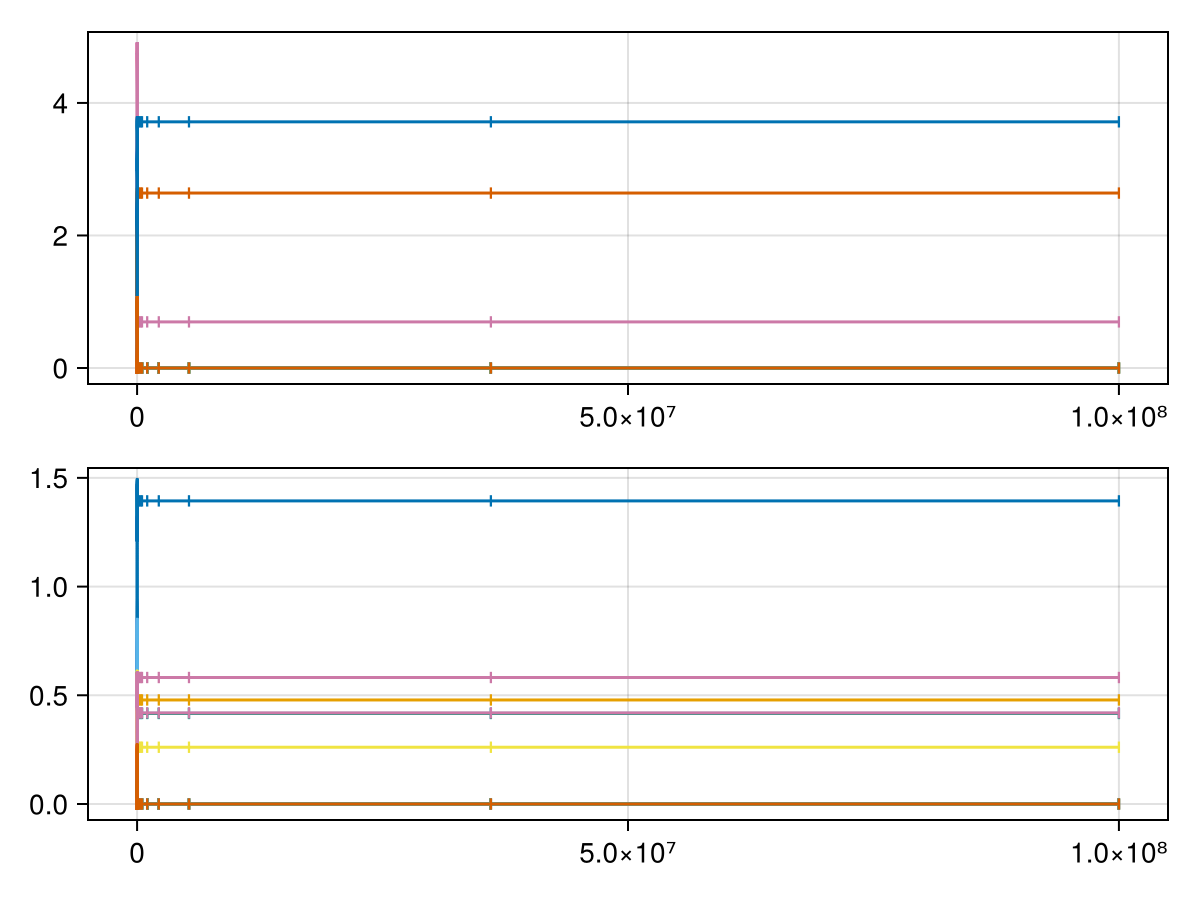

In [14]:
fig = plot_mmicrm_sol(s).figure
# display(GLMakie.Screen(), fig)

# Some ODEs take long - seems like a QNDF thing?

In [7]:
f = jldopen("../si_early_times/data4.jld2")

fmetadata = f["metadata"]
N = fmetadata.N
M = fmetadata.M
dx = fmetadata.dx
sN = fmetadata.sN
Klips = fmetadata.Klips_to_run

Klips_matrix = Matrix{typeof(Klips[1])}(undef, fmetadata.num_runs, length(Klips))
for ii in 1:length(Klips)
    Klips_matrix[:,ii] .= Ref(Klips[ii])
end;

# second index sets the Klip set, first index the run index
fparams = f["params"]
fode_rcs = f["ode_retcodes"]
fode_fTs = f["ode_final_Ts"]
fode_fss = f["ode_final_states"]
fpde_fTs = f["pde_final_Ts"]
fpde_fss = f["pde_final_states"]
fpde_rcs = f["pde_retcodes"]
fpde_dls = f["pde_dom_length"];

In [23]:
# Make a dataframe with all results
df = DataFrame(;
    K=getindex.(Klips_matrix, 1)[:],
    l=getindex.(Klips_matrix, 1)[:],
    p=getindex.(Klips_matrix, 1)[:],
    params=fparams[:],
    ode_rc=fode_rcs[:],
    ode_fT=fode_fTs[:],
    ode_fs=fode_fss[:],
    pde_rc=fpde_rcs[:],
    pde_fT=fpde_fTs[:],
    pde_fs=fpde_fss[:],
    dl=fpde_dls[:],
    Lmax=map(Klips_matrix) do Klip fr2_Lmax(Klip...) end[:],
);

df.ode_fs_tbiom = map(df.ode_fs) do fs sum(fs[1:N]) end;
df.pde_fs_biom = map(df.pde_fs) do fs get_total_biomass_1d(fs, N) end;
df.pde_fs_tbiom = sum.(df.pde_fs_biom);

@show nrow(df), names(df)

gdf = @subset(df,
    :ode_rc .== ReturnCode.Success,
    :pde_rc .== ReturnCode.Terminated,
    :ode_fs_tbiom .> 1e-9,
    # :pde_fs_tbiom .> 1e-9,
)
nrow(gdf)

(nrow(df), names(df)) = (300, ["K", "l", "p", "params", "ode_rc", "ode_fT", "ode_fs", "pde_rc", "pde_fT", "pde_fs", "dl", "Lmax", "ode_fs_tbiom", "pde_fs_biom", "pde_fs_tbiom"])


234

In [37]:
fis = findall(!=(ReturnCode.Success), df.ode_rc)
fdf = df[fis,:];
nrow(fdf)

29

In [45]:
# fr = fdf[end,:]
fr = df[end,:]
ps = fr.params
ode_ps = ps.mmicrm_params
u0 = copy(fmetadata.ode_u0);

In [53]:
T = 1e8
tol = 1e-9

p = make_mmicrm_problem(ode_ps, u0, T);
# @time s = solve(p, QNDF();
@time s = solve(p, TRBDF2();
    abstol=tol,
    reltol=tol,
);
s.retcode, mmicrmmaxresid(s)

  0.059727 seconds (2.79 k allocations: 894.391 KiB)


(SciMLBase.ReturnCode.Success, 4.130155639952844e-13)

In [54]:
f = plot_mmicrm_sol(s).figure
display(GLMakie.Screen(), f)

GLMakie.Screen(...)

# OLD

In [4]:
N = 20
M = N
B = 3
rsg = get_si_sampler_for_paper(15, 1.; N, M, B);

In [5]:
ps = rsg().mmicrm_params;
N, M = get_Ns(ps)

num_repeats = 20

tol = 1e-9

sols = Vector{Any}(undef, num_repeats)
fss = Vector{Any}(undef, num_repeats)

@tasks for i in 1:num_repeats
    u0 = zeros(N+M)
    for i in 1:N
        u0[i] = 1000 * rand()
    end
    p = make_mmicrm_problem(ps, u0, 1e8);
    s = solve(p, QNDF();
        abstol=tol,
        reltol=tol,
    );
    sols[i] = s
    fss[i] = s.u[end]
end

maximum(map(mmicrmmaxresid, sols))

1.979799183091203e-12

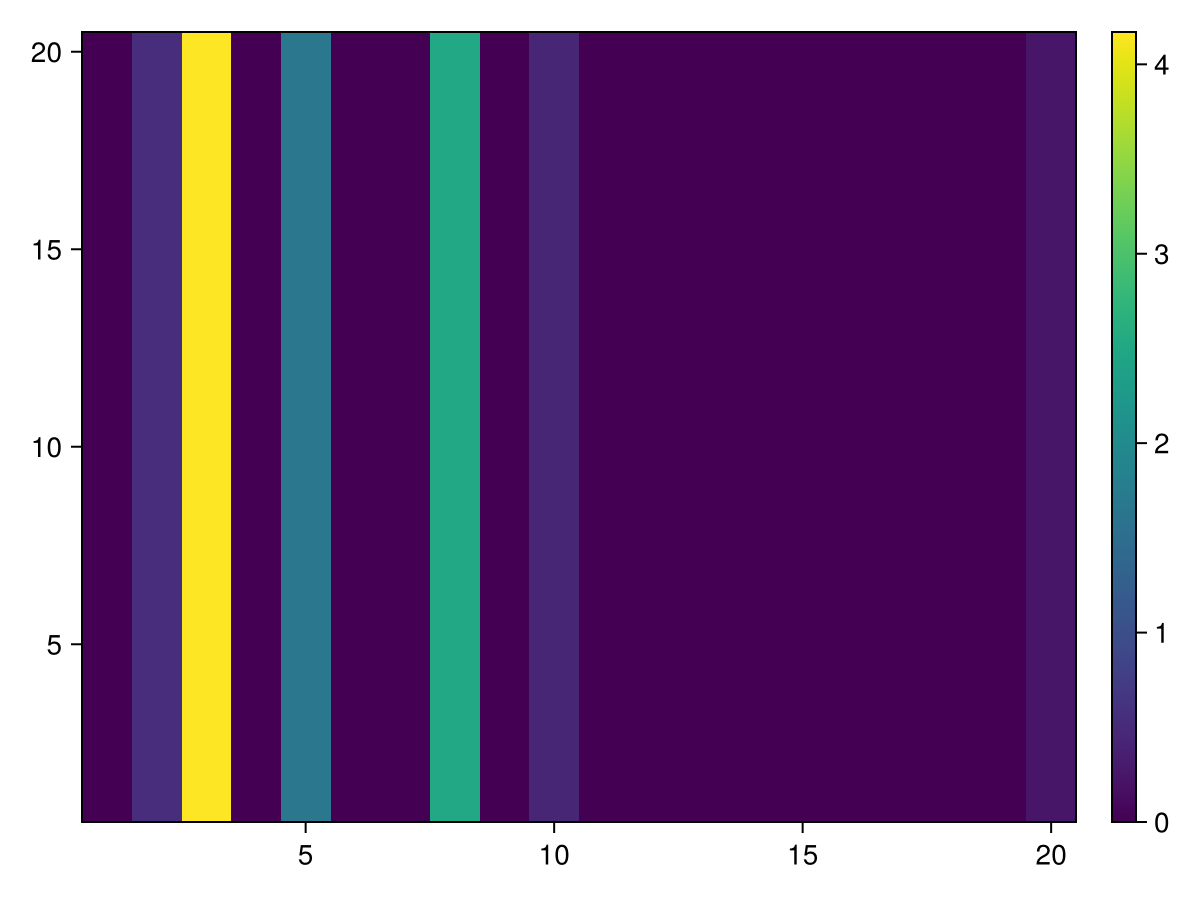

In [6]:
fap = heatmap(hcat([x[1:N] for x in fss]...))
# fap = heatmap(hcat(fss...))
Colorbar(fap.figure[1,2], fap.plot)
fap

In [7]:
s = sols[end-2];

In [85]:
f = plot_mmicrm_sol(s).figure
display(GLMakie.Screen(), f)

GLMakie.Screen(...)

In [31]:
ps = copy(s.prob.p)
u0 = copy(s.prob.u0)
bad_sol = copy(s);

In [45]:
@time s = solve(bad_sol.prob, QNDF();
        abstol=tol,
        reltol=tol,
    );

  0.085523 seconds (10.31 k allocations: 3.217 MiB)


┌ Warning: At t=818.1316364157518, dt was forced below floating point epsilon 1.1368683772161603e-13, and step error estimate = 1.0080770157563541. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:673


In [78]:
fake_ood(u, p, t) = false
real_ood(u, p, t) = any(x->x<0., u)

real_ood (generic function with 1 method)

In [79]:
@time s = solve(bad_sol.prob, QNDF();
        abstol=tol,
        reltol=tol,
        # isoutofdomain=fake_ood,
        isoutofdomain=real_ood,
    );

 31.687082 seconds (1.75 M allocations: 519.561 MiB, 0.34% compilation time: 100% of which was recompilation)


┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:626


In [98]:
@time s = solve(bad_sol.prob, QNDF();
        abstol=tol,
        reltol=tol,
        callback=CallbackSet(PositiveDomain(copy(bad_sol.prob.u0)), make_timer_callback(5)),
        # callback=PositiveDomain(copy(bad_sol.prob.u0)),
        # isoutofdomain=fake_ood,
        # isoutofdomain=real_ood,
    );

  1.775660 seconds (413.13 k allocations: 130.455 MiB)


In [64]:
maximum(abs, s.u[end] .- bad_sol.u[end])

1.5801488638798672e11